In [1]:
# Remove noise from image using auto encoder network 
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.python.keras.models import Sequential
from tensorflow.python.keras.layers import Conv2D, MaxPooling2D, UpSampling2D

In [2]:
# Reproducibility
np.random.seed(100)

# Load data
(x_train, _), (x_test, _) = tf.keras.datasets.mnist.load_data()

# Normalize to [0,1]
x_train = x_train.astype("float32") / 255.0
x_test  = x_test.astype("float32") / 255.0

# Reshape to (N, 28, 28, 1)
x_train = x_train[..., np.newaxis]
x_test  = x_test[..., np.newaxis]

# Add Gaussian noise
noise_factor = 0.7
x_train_noisy = x_train + noise_factor * np.random.normal(
    loc=0.0, scale=1.0, size=x_train.shape
)
x_test_noisy = x_test + noise_factor * np.random.normal(
    loc=0.0, scale=.5, size=x_test.shape
)

# Clip to valid range
x_train_noisy = np.clip(x_train_noisy, 0., 1.)
x_test_noisy  = np.clip(x_test_noisy, 0., 1.)
x_train_noisy.shape

(60000, 28, 28, 1)

In [3]:
model = Sequential()

# ---------- Encoder ----------
model.add(Conv2D(32, (3, 3), activation='relu', padding='same',
                 input_shape=(28, 28, 1)))
model.add(Conv2D(32, (3,3), activation='relu', padding='same'))
model.add(MaxPooling2D((2, 2), padding='same'))

model.add(Conv2D(16, (3, 3), activation='relu', padding='same'))
model.add(Conv2D(16, (3, 3), activation='relu', padding='same'))
model.add(MaxPooling2D((2, 2), padding='same'))


model.add(Conv2D(8, (3, 3), activation='relu', padding='same')) # bottleneck 
model.add(Conv2D(8, (3, 3), activation='relu', padding='same')) # deeber bottleneck 

# ---------- Decoder ----------
model.add(Conv2D(8, (3, 3), activation='relu', padding='same'))
model.add(Conv2D(8, (3, 3), activation='relu', padding='same'))
model.add(UpSampling2D((2, 2)))

model.add(Conv2D(16, (3, 3), activation='relu', padding='same'))
model.add(Conv2D(16, (3, 3), activation='relu', padding='same'))
model.add(UpSampling2D((2, 2)))

model.add(Conv2D(32, (3, 3), activation='relu', padding='same'))

# Output layer
model.add(Conv2D(1, (3, 3), activation='sigmoid', padding='same',  kernel_initializer='he_normal'))

model.compile(
    optimizer='adam',
    loss='binary_crossentropy' #'mean_squared_error'
)

model.summary()

Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
conv2d (Conv2D)              (None, 28, 28, 32)        320       
_________________________________________________________________
conv2d_1 (Conv2D)            (None, 28, 28, 32)        9248      
_________________________________________________________________
max_pooling2d (MaxPooling2D) (None, 14, 14, 32)        0         
_________________________________________________________________
conv2d_2 (Conv2D)            (None, 14, 14, 16)        4624      
_________________________________________________________________
conv2d_3 (Conv2D)            (None, 14, 14, 16)        2320      
_________________________________________________________________
max_pooling2d_1 (MaxPooling2 (None, 7, 7, 16)          0         
_________________________________________________________________
conv2d_4 (Conv2D)            (None, 7, 7, 8)           1

In [4]:
history = model.fit(
    x_train_noisy, x_train,
    epochs=30,
    batch_size=128,
    shuffle=True,
    validation_data=(x_test_noisy, x_test)
)

Epoch 1/30
469/469 [==============================] - 12s 18ms/step - loss: 0.2122 - val_loss: 0.1242
Epoch 2/30
469/469 [==============================] - 8s 16ms/step - loss: 0.1413 - val_loss: 0.1097
Epoch 3/30
469/469 [==============================] - 8s 16ms/step - loss: 0.1330 - val_loss: 0.1026
Epoch 4/30
469/469 [==============================] - 8s 16ms/step - loss: 0.1291 - val_loss: 0.0989
Epoch 5/30
469/469 [==============================] - 8s 16ms/step - loss: 0.1268 - val_loss: 0.0979
Epoch 6/30
469/469 [==============================] - 8s 16ms/step - loss: 0.1251 - val_loss: 0.0961
Epoch 7/30
469/469 [==============================] - 8s 16ms/step - loss: 0.1239 - val_loss: 0.0958
Epoch 8/30
469/469 [==============================] - 8s 16ms/step - loss: 0.1228 - val_loss: 0.0956
Epoch 9/30
469/469 [==============================] - 8s 16ms/step - loss: 0.1219 - val_loss: 0.0942
Epoch 10/30
469/469 [==============================] - 8s 16ms/step - loss: 0.1212 - val_l

In [5]:
decoded_imgs = model.predict(x_test_noisy)

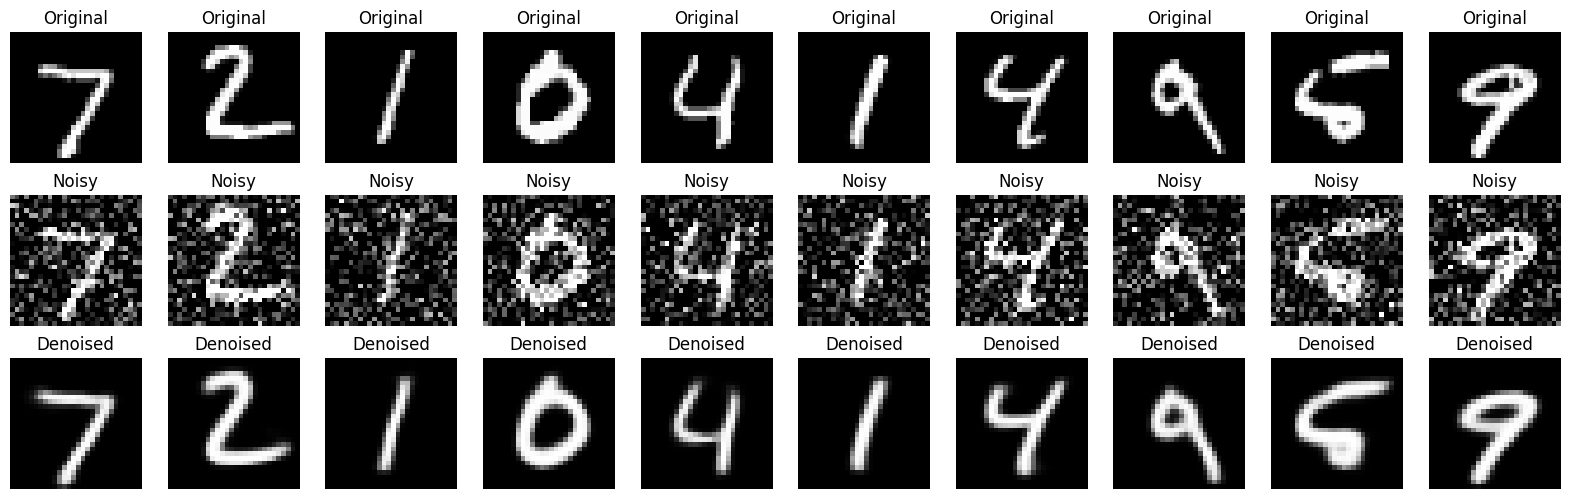

In [6]:
n = 10
plt.figure(figsize=(20, 6))

for i in range(n):
    # Original
    ax = plt.subplot(3, n, i + 1)
    plt.imshow(x_test[i].reshape(28, 28), cmap="gray")
    plt.title("Original")
    plt.axis("off")

    # Noisy
    ax = plt.subplot(3, n, i + 1 + n)
    plt.imshow(x_test_noisy[i].reshape(28, 28), cmap="gray")
    plt.title("Noisy")
    plt.axis("off")

    # Denoised
    ax = plt.subplot(3, n, i + 1 + 2*n)
    plt.imshow(decoded_imgs[i].reshape(28, 28), cmap="gray")
    plt.title("Denoised")
    plt.axis("off")

plt.show()
